In [24]:
import sys
sys.path.append('../src')

In [43]:
import pandas as pd

In [27]:
import matplotlib.pyplot as plt

In [6]:
from coletor import coletar_indicadores, tratar_dados

In [7]:
indicadores = {'selic': 11, 'ipca': 433}
df_bruto = coletar_indicadores(indicadores)

Iniciando coleta de: ['selic', 'ipca']
Dados baixados com sucesso


In [9]:
df_bruto.head()

,selic,ipca
Date,,
2023-01-01,NaN,0.53
2023-01-02,0.050788,NaN
2023-01-03,0.050788,NaN
2023-01-04,0.050788,NaN
2023-01-05,0.050788,NaN


In [11]:
df_bruto.tail()

,selic,ipca
Date,,
2026-04-24,0.054266,NaN
2026-04-27,0.054266,NaN
2026-04-28,0.054266,NaN
2026-04-29,0.054266,NaN
2026-04-30,0.053400,NaN


In [13]:
len(df_bruto)

854

In [14]:
df_bruto.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 854 entries, 2023-01-01 to 2026-04-30
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   selic   835 non-null    float64
 1   ipca    39 non-null     float64
dtypes: float64(2)
memory usage: 20.0 KB


In [15]:
df_bruto.describe()

,selic,ipca
count,835.000000,39.000000
mean,0.048402,0.393846
std,0.005797,0.281945
min,0.039270,-0.110000
25%,0.041957,0.230000
50%,0.050788,0.380000
75%,0.054266,0.545000
max,0.055131,1.310000


In [38]:
df_teste = df_bruto.ffill().bfill()
df_teste.head(35)

,selic,ipca
Date,,
2023-01-01,0.050788,0.53
2023-01-02,0.050788,0.53
2023-01-03,0.050788,0.53
2023-01-04,0.050788,0.53
2023-01-05,0.050788,0.53
2023-01-06,0.050788,0.53
2023-01-09,0.050788,0.53
2023-01-10,0.050788,0.53
2023-01-11,0.050788,0.53


In [39]:
df_teste.isnull().sum()

selic    0
ipca     0
dtype: int64

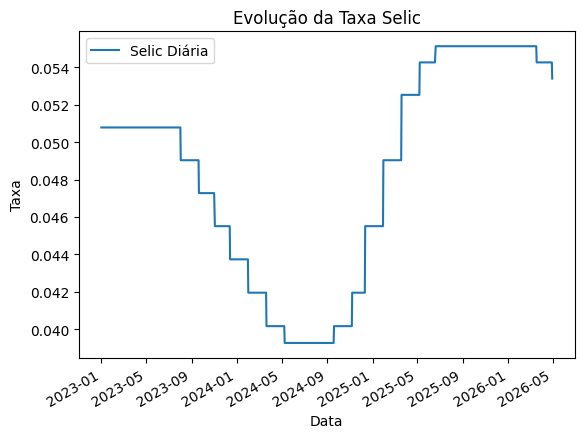

In [40]:
df_teste['selic'].plot(legend=True, label="Selic Diária")
plt.title('Evolução da Taxa Selic')
plt.xlabel('Data')
plt.ylabel('Taxa')
plt.show()

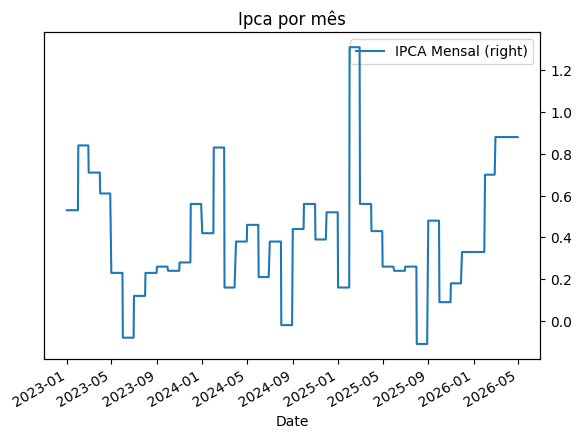

In [41]:
df_teste['ipca'].plot(secondary_y=True,legend=True, label='IPCA Mensal')
plt.title('Ipca por mês')
plt.show()

In [44]:
df_validacao = pd.read_json('../data/indicadores_mercado.json')

print('Teste de integridade:')
print(df_validacao.head())
print(f'\nTotal de linhas salvas: {len(df_validacao)}')

Teste de integridade:
                      data     selic  ipca
0  2023-01-01T00:00:00.000  0.050788  0.53
1  2023-01-02T00:00:00.000  0.050788  0.53
2  2023-01-03T00:00:00.000  0.050788  0.53
3  2023-01-04T00:00:00.000  0.050788  0.53
4  2023-01-05T00:00:00.000  0.050788  0.53

Total de linhas salvas: 854
